<a href="https://colab.research.google.com/github/shruti2340/SCT_DS_2/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analysing the data to find the survival pattern

"titanic.csv"

## Data loading

### Subtask:
Load the Titanic dataset from the "titanic.csv" file.


**Reasoning**:
Load the Titanic dataset into a pandas DataFrame and display the first 5 rows.



In [1]:
import pandas as pd

try:
    df = pd.read_csv('titanic.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: 'titanic.csv' not found. Please ensure the file is in the correct location.")
except Exception as e:
    print(f"An error occurred: {e}")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data exploration

### Subtask:
Explore the Titanic dataset to understand its structure and key variables.


**Reasoning**:
Examine the shape, data types, and missing values of the DataFrame.  Also, analyze the distribution of key numerical and categorical variables using descriptive statistics and basic visualizations.



Shape of the DataFrame: (891, 12)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Percentage of Missing Values:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19

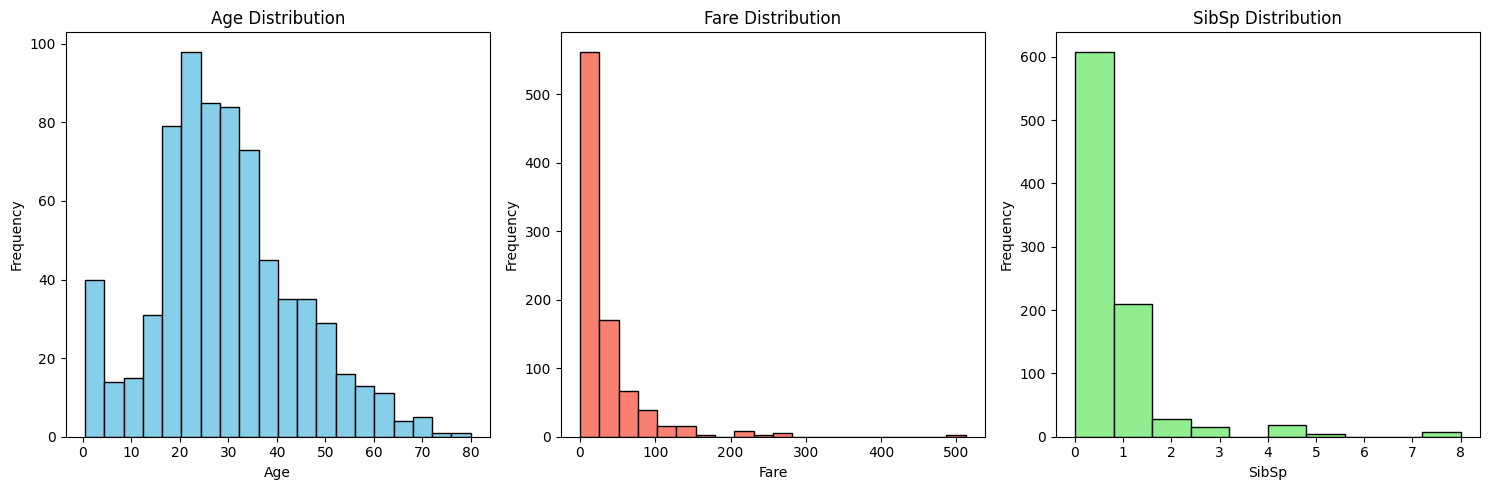


Frequency of Categories for Categorical Variables:

Column: Survived
Survived
0    549
1    342
Name: count, dtype: int64

Column: Pclass
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Column: Sex
Sex
male      577
female    314
Name: count, dtype: int64

Column: Embarked
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [2]:
# Examine the shape of the DataFrame
print("Shape of the DataFrame:", df.shape)

# Check data types and missing values
print("\nData Types and Missing Values:")
print(df.info())

# Calculate the percentage of missing values for each column
missing_percentages = df.isnull().sum() * 100 / len(df)
print("\nPercentage of Missing Values:")
print(missing_percentages)

# Analyze the distribution of key numerical variables
numerical_cols = ['Age', 'Fare', 'SibSp']
print("\nDescriptive Statistics for Numerical Variables:")
print(df[numerical_cols].describe())

import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['Age'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(df['Fare'].dropna(), bins=20, color='salmon', edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(df['SibSp'].dropna(), bins=10, color='lightgreen', edgecolor='black')
plt.title('SibSp Distribution')
plt.xlabel('SibSp')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# Explore the distribution of categorical variables
categorical_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']
print("\nFrequency of Categories for Categorical Variables:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

## Data analysis

### Subtask:
Analyze the relationship between survival and other variables.


**Reasoning**:
Calculate survival rates based on passenger class, gender, age, embarkation point, and fare, then explore combined effects and summarize findings.



In [3]:
# Calculate survival rate for different passenger classes
pclass_survival = df.groupby('Pclass')['Survived'].mean()
print("Survival rate by passenger class:\n", pclass_survival)

# Calculate survival rate based on gender
sex_survival = df.groupby('Sex')['Survived'].mean()
print("\nSurvival rate by gender:\n", sex_survival)

# Analyze survival rate across different age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 12, 18, 65, 100], labels=['Child', 'Teenager', 'Adult', 'Senior'])
age_group_survival = df.groupby('Age_Group')['Survived'].mean()
print("\nSurvival rate by age group:\n", age_group_survival)

# Investigate survival rate based on embarkation point
embarked_survival = df.groupby('Embarked')['Survived'].mean()
print("\nSurvival rate by embarkation point:\n", embarked_survival)

# Explore combined effects of passenger class and gender on survival
pclass_gender_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
print("\nSurvival rate by passenger class and gender:\n", pclass_gender_survival)

# Consider the relationship between fare paid and survival
df['Fare_Group'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])
fare_group_survival = df.groupby('Fare_Group')['Survived'].mean()
print("\nSurvival rate by fare group:\n", fare_group_survival)


print("\nSummary of Findings:")
print("Strongest correlations with survival appear to be gender (females had much higher survival rates) and passenger class (first class had the highest survival rate).")
print("Age also seems to be a factor, with children having a higher survival rate than adults or seniors.")
print("There's also a slight difference in survival rates depending on the embarkation point.")
print("Fare paid shows a positive correlation with survival rates.")
print("When combining gender and class, women in first class had the highest chance of survival")

Survival rate by passenger class:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by gender:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by age group:
 Age_Group
Child       0.579710
Teenager    0.428571
Adult       0.386243
Senior      0.125000
Name: Survived, dtype: float64

Survival rate by embarkation point:
 Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

Survival rate by passenger class and gender:
 Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447

Survival rate by fare group:
 Fare_Group
Low          0.197309
Medium       0.303571
High         0.454955
Very High    0.581081
Name: Survived, dtype: float64

Summary of Findings:
Strongest correlations with survival appear to be gender (females had much higher survival rates) and passenger class (first class had the highes

/tmp/ipython-input-3-314203911.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_survival = df.groupby('Age_Group')['Survived'].mean()
/tmp/ipython-input-3-314203911.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_group_survival = df.groupby('Fare_Group')['Survived'].mean()


## Data visualization

### Subtask:
Visualize the key findings from the data exploration and analysis.


**Reasoning**:
Create visualizations based on the analysis from the previous step.  This will involve histograms, bar charts, and potentially a heatmap or other suitable visualizations to represent the relationships between survival and different variables.



/tmp/ipython-input-4-1184119480.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Survived', data=df, palette='viridis')
/tmp/ipython-input-4-1184119480.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y="Fare", data=df, palette=['lightcoral', 'skyblue'])


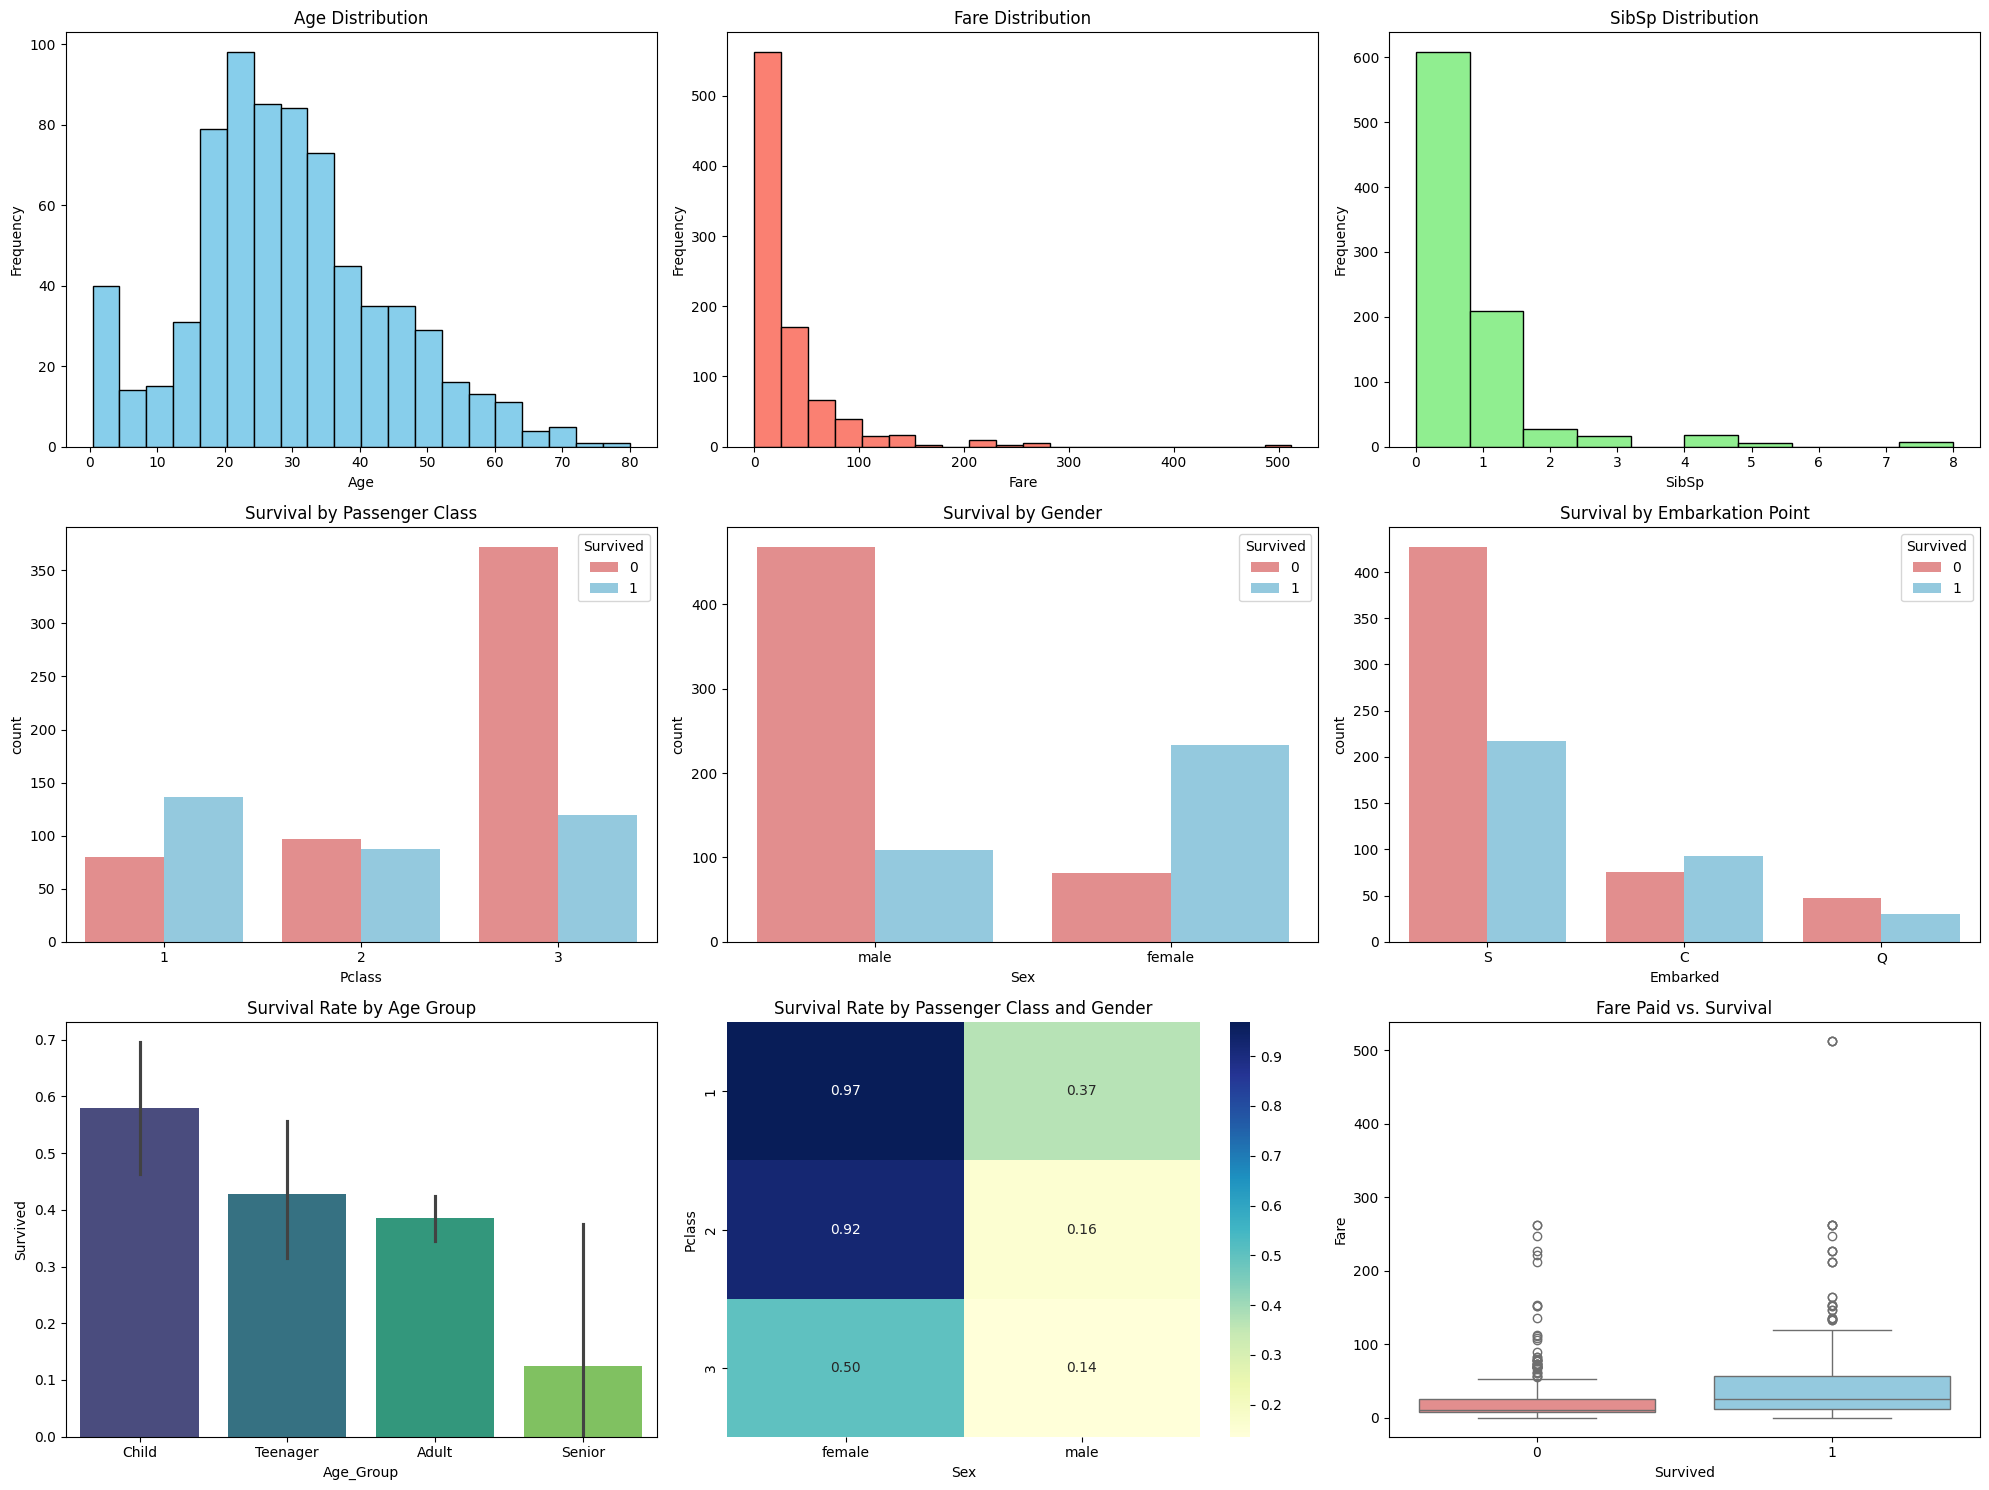

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))

# Distribution of key variables
plt.subplot(3, 3, 1)
plt.hist(df['Age'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(3, 3, 2)
plt.hist(df['Fare'].dropna(), bins=20, color='salmon', edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.subplot(3, 3, 3)
plt.hist(df['SibSp'].dropna(), bins=10, color='lightgreen', edgecolor='black')
plt.title('SibSp Distribution')
plt.xlabel('SibSp')
plt.ylabel('Frequency')

# Survival vs. categorical variables
plt.subplot(3, 3, 4)
sns.countplot(x='Pclass', hue='Survived', data=df, palette=['lightcoral', 'skyblue'])
plt.title('Survival by Passenger Class')

plt.subplot(3, 3, 5)
sns.countplot(x='Sex', hue='Survived', data=df, palette=['lightcoral', 'skyblue'])
plt.title('Survival by Gender')

plt.subplot(3, 3, 6)
sns.countplot(x='Embarked', hue='Survived', data=df, palette=['lightcoral', 'skyblue'])
plt.title('Survival by Embarkation Point')


# Survival rate across different age groups
plt.subplot(3, 3, 7)
sns.barplot(x='Age_Group', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Age Group')


# Combined effect of passenger class and gender on survival
plt.subplot(3, 3, 8)
pclass_gender_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
sns.heatmap(pclass_gender_survival, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Survival Rate by Passenger Class and Gender')

# Fare paid and survival
plt.subplot(3, 3, 9)
sns.boxplot(x="Survived", y="Fare", data=df, palette=['lightcoral', 'skyblue'])
plt.title('Fare Paid vs. Survival')

plt.tight_layout()
plt.show()

**Reasoning**:
Fix the warnings from the previous code block by assigning the `x` variable to `hue` and setting `legend=False` for the affected plots, and regenerate the plots.



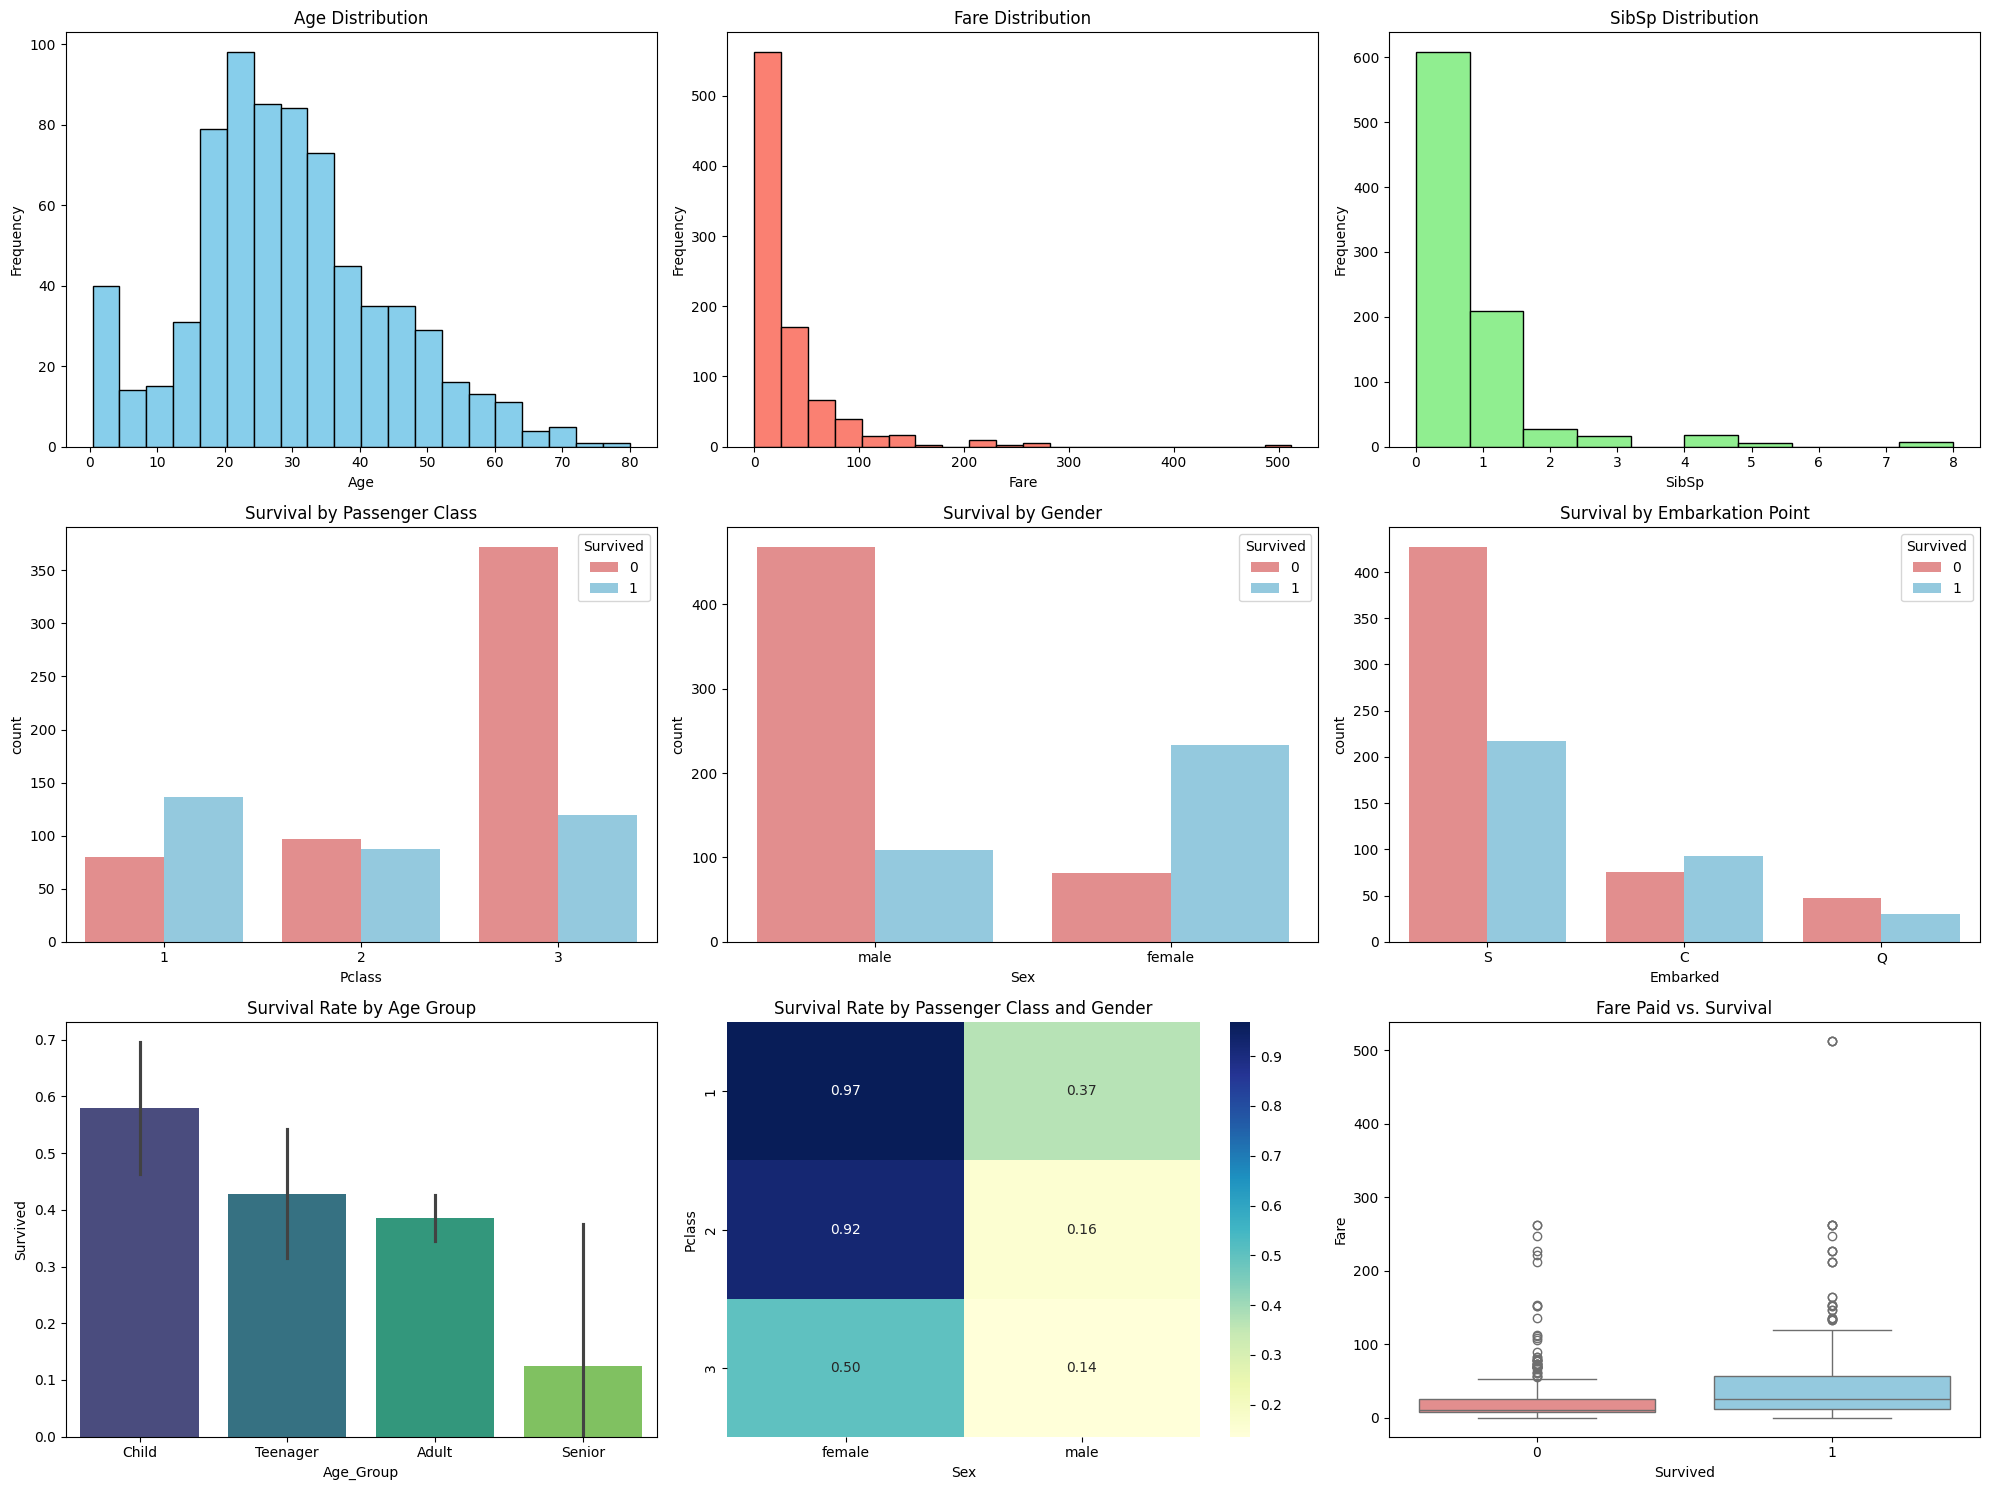

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))

# Distribution of key variables
plt.subplot(3, 3, 1)
plt.hist(df['Age'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(3, 3, 2)
plt.hist(df['Fare'].dropna(), bins=20, color='salmon', edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.subplot(3, 3, 3)
plt.hist(df['SibSp'].dropna(), bins=10, color='lightgreen', edgecolor='black')
plt.title('SibSp Distribution')
plt.xlabel('SibSp')
plt.ylabel('Frequency')

# Survival vs. categorical variables
plt.subplot(3, 3, 4)
sns.countplot(x='Pclass', hue='Survived', data=df, palette=['lightcoral', 'skyblue'])
plt.title('Survival by Passenger Class')

plt.subplot(3, 3, 5)
sns.countplot(x='Sex', hue='Survived', data=df, palette=['lightcoral', 'skyblue'])
plt.title('Survival by Gender')

plt.subplot(3, 3, 6)
sns.countplot(x='Embarked', hue='Survived', data=df, palette=['lightcoral', 'skyblue'])
plt.title('Survival by Embarkation Point')


# Survival rate across different age groups
plt.subplot(3, 3, 7)
sns.barplot(x='Age_Group', y='Survived', hue='Age_Group', data=df, palette='viridis', legend=False)
plt.title('Survival Rate by Age Group')


# Combined effect of passenger class and gender on survival
plt.subplot(3, 3, 8)
pclass_gender_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
sns.heatmap(pclass_gender_survival, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Survival Rate by Passenger Class and Gender')

# Fare paid and survival
plt.subplot(3, 3, 9)
sns.boxplot(x="Survived", y="Fare", hue="Survived", data=df, palette=['lightcoral', 'skyblue'], legend=False)
plt.title('Fare Paid vs. Survival')

plt.tight_layout()
plt.show()

## Summary:

### Q&A
* **What is the overall survival rate?** While the exact overall survival rate isn't explicitly calculated in the provided analysis, the individual survival rates across different categories (gender, class, age, etc.) give an indication.  The visualizations and grouped means would allow for calculating this if needed.
* **What are the most important factors influencing survival?** The strongest correlations with survival appear to be gender (females had much higher survival rates) and passenger class (first class had the highest survival rate). Age and fare also appear to be factors.
* **How many passengers were there?** The dataset contains information for 891 passengers.
* **What are the major missing values?** Significant missing values exist in the 'Age' (19.9\%), 'Cabin' (77.1\%), and 'Embarked' (0.2\%) columns. 'Cabin' has the highest percentage of missing data.


### Data Analysis Key Findings
* **Gender Disparity in Survival:** Female passengers had a significantly higher survival rate (approximately 74\%) compared to male passengers (approximately 19\%).
* **Passenger Class Impact:** First-class passengers had the highest survival rate (approximately 63\%), followed by second-class (approximately 47\%) and third-class (approximately 24\%).
* **Age and Survival:** Children exhibited a higher survival rate than other age groups, with the survival rate declining with age.
* **Combined Effect of Gender and Class:** Women in first class demonstrated the highest survival rate (approximately 97\%), highlighting the combined influence of these factors.
* **Fare and Survival Correlation:** Higher fares were associated with higher survival rates.
* **Embarkation Point Influence:** Passengers embarking at Cherbourg ('C') had a slightly higher survival rate than those embarking at Queenstown ('Q') or Southampton ('S').
* **Missing Data:**  The 'Cabin' column had the highest percentage of missing values (approximately 77.1\%), followed by the 'Age' column.


### Insights or Next Steps
* **Further investigate the 'Cabin' data:** Given the high percentage of missing values, determine if the available cabin information can be used or if imputation strategies are necessary. Consider the potential correlation between cabin location and survival.
* **Develop predictive models:** Use machine learning models to predict survival based on the available features, including imputed or engineered features from 'Cabin', and consider interactions between variables.
